In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calplot
import json
import plotly.express as px
import plotly.graph_objects as go

# Complaints

## 1. Dataset overview

Collect complaints from NYC Open Data <br> 
(https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

- from 1 january 2021 to 31 december 2025 (created_date column)
- complaint types selected
    - Heat/Hot water
    - Unsanitary condition
    - Water leak
    - Plumbing
    - Electric
- 2.468.069 complaints

In [2]:
df_complaints=pd.read_csv("data/complaints20_25_original.csv")
print(df_complaints.isna().sum())
df_complaints = df_complaints.drop(columns=["agency_name"])
df_complaints.head()

unique_key        0
created_date      0
agency_name       0
complaint_type    0
incident_zip      0
borough           0
dtype: int64


,unique_key,created_date,complaint_type,incident_zip,borough
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,BROOKLYN
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,BROOKLYN
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,MANHATTAN
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,MANHATTAN
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,BRONX


In [3]:
print(f"Number of complaints: {len(df_complaints)}")

df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"]) #add smth for errors
print(f"Date range: {df_complaints["created_date"].min()}, {df_complaints["created_date"].max()}")

unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")

Number of complaints: 2468069
Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56
Number of types of complaints: 5
Types of compaints: ['HEAT/HOT WATER', 'PLUMBING', 'WATER LEAK', 'UNSANITARY CONDITION', 'ELECTRIC']
Number of different zipcodes: 211
Number of different boroughs: 5


In [4]:
df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"])
min_date=df_complaints['created_date'].min()
max_date=df_complaints['created_date'].max()
print(f"Date range: {min_date}, {max_date}")

Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56


## 2. Complaints per type, borough and zip code

Most complaints are clearly Heat/Hot water. <br>
Bronx has the highest number of complaints.

In [5]:
print(f"Number of complaints per type:\n {df_complaints["complaint_type"].value_counts()}")

comp_borough=df_complaints["borough"].value_counts()
print(f"\nNumber of complaints per borough:\n {comp_borough}")

comp_zip=df_complaints["incident_zip"].value_counts()
print(f"\nTop 5 Number of complaints per zip code:\n {comp_zip.head(5)}")

Number of complaints per type:
 complaint_type
HEAT/HOT WATER          1275874
UNSANITARY CONDITION     544864
PLUMBING                 307730
WATER LEAK               201973
ELECTRIC                 137628
Name: count, dtype: int64

Number of complaints per borough:
 borough
BRONX            860267
BROOKLYN         704758
MANHATTAN        535979
QUEENS           325246
STATEN ISLAND     41819
Name: count, dtype: int64

Top 5 Number of complaints per zip code:
 incident_zip
11226    79734
10452    75280
10457    73395
10458    72942
10467    72182
Name: count, dtype: int64


The number of complaints per borough and per zip should take into account population per borough and per zip. <br>
The population by borough was fetched from https://data.cityofnewyork.us/City-Government/2020-population/t8c6-3i7b/about_data and the population by zip from https://www.newyork-demographics.com/zip_codes_by_population. <br>
The number of complaints per 1000 people was computed for each borough and for each zip code, seperatly.

In [6]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
# complaints per borough
comp_borough = df_complaints["borough"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
# complaints per 1000 people per borough
complaints_per_1000 = (comp_borough / borough_pop) * 1000
df_rates = pd.DataFrame({
    "complaints": comp_borough,
    "population": borough_pop,
    "complaints_per_1000": complaints_per_1000
})
df_rates

,complaints,population,complaints_per_1000
BRONX,860267,1446788,594.604738
BROOKLYN,704758,2648452,266.101859
MANHATTAN,535979,1638281,327.159382
QUEENS,325246,2330295,139.572887
STATEN ISLAND,41819,487155,85.843315


In [7]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)

# complaints per zip
comp_zip_df = comp_zip.rename_axis("Zip Code").reset_index(name="complaints")
comp_zip_pop = comp_zip_df.merge(zip_pop, on="Zip Code", how="left")

# complaints per 1000 people per zip
comp_zip_pop["complaints_1000"]=(comp_zip_pop["complaints"]/comp_zip_pop["Population"])*1000

Save a choropleth map of complaints per 1000 per zip code. Zip codes with no value do not appear colored. <br>

The .geojson file for NYC zip codes was fetched from https://www.kaggle.com/datasets/saidakbarp/nyc-zipcode-geodata

In [8]:
min_range=comp_zip_pop["complaints_1000"].min()
max_range=comp_zip_pop["complaints_1000"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "complaints_1000": True
    },
    labels={
        "complaints_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Complaints per 1000 residents")

min_range=comp_zip_pop["complaints_1000"].min()
max_range=comp_zip_pop["complaints_1000"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "complaints_1000": True
    },
    labels={
        "complaints_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Complaints per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    # white shadow layer
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"] + 0.003],
        lat=[label["lat"] - 0.003],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
        below="",
    ))
    # dark text on top
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="#1a1814", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
        below="",
    ))

fig.write_html("data/visualizations/complaints/zip_complaints_map.html")


C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1020805272.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1020805272.py:45: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1020805272.py:80: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1020805272.py:91: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


Map with line around boroughs

In [9]:
min_range = comp_zip_pop["complaints_1000"].min()
max_range = comp_zip_pop["complaints_1000"].max()

# borough geojson
with open("data/geojson/new-york-city-boroughs.geojson") as f:
    borough_geo = json.load(f)

# borough zip
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={"Zip Code": True, "complaints_1000": True},
    labels={"complaints_1000": "Complaints"}
)

fig.update_layout(
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    mapbox={
        "layers": [
            {
                "source": borough_geo,
                "type": "line",
                "color": "grey",
                "line": {"width": 2},
            }
        ]
    }
)

fig.update_coloraxes(colorbar_title="Complaints per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))
fig.write_html("data/visualizations/complaints/zip_complaints_map_test.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1799734361.py:15: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1799734361.py:54: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 3. Yearly trends per type and borough

In [10]:
# df_complaints["year"] = df_complaints["created_date"].dt.year
# year_type = df_complaints.groupby(["year", "complaint_type"]).size().unstack(fill_value=0)
# year_type

In [11]:
# comp_types = year_type.columns.tolist()
# years = sorted(year_type.index.tolist())

# fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# axes = axes.flatten()

# for i, cat in enumerate(comp_types):
#     values = year_type[cat].values
#     axes[i].plot(years, values, color="coral", marker='o')
#     axes[i].set_title(cat.capitalize(), fontsize=16)
#     axes[i].set_xlabel("Year", fontsize=14)
#     axes[i].set_xticks(years)
#     axes[i].set_xticklabels(years, fontsize=14)
#     axes[i].set_ylabel("Number of complaints", fontsize=14)
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# # Remove the unused subplot
# for j in range(len(comp_types), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Yearly Trends in Housing Complaint Types", fontsize=26)
# plt.tight_layout()
# plt.show()


Yearly trend per borough must take into account borough population. <br>
The Bronx clearly rates higher than all other boroughs for every year.

In [12]:
df_complaints["year"] = df_complaints["created_date"].dt.year
year_boro = df_complaints.groupby(["year", "borough"]).size().unstack(fill_value=0)
year_boro_norm = year_boro.div(borough_pop, axis=1) * 1000
print(year_boro_norm)

borough       BRONX   BROOKLYN  MANHATTAN     QUEENS  STATEN ISLAND
year                                                               
2021      95.482545  45.233971  51.897080  22.206201      14.785848
2022     117.592211  52.565423  62.734659  27.103006      17.505722
2023     116.339090  52.332834  64.260038  27.388378      19.349078
2024     127.584000  55.830727  68.222729  31.018820      16.885796
2025     137.606892  60.138904  80.044876  31.856482      17.316870


In [13]:
# boroughs = year_boro.columns.tolist()

# fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# axes = axes.flatten()

# for i, borough in enumerate(boroughs):
#     axes[i].plot(
#         year_boro_norm.index,
#         year_boro_norm[borough],
#         marker='o',
#         color='coral'
#     )
#     axes[i].set_title(borough.capitalize(), fontsize=16)
#     axes[i].set_xlabel("Year", fontsize=14)
#     axes[i].set_xticks(years)
#     axes[i].set_xticklabels(years, fontsize=14)
#     axes[i].set_ylabel("Number of complaints", fontsize=14)
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# # Remove the unused subplot
# for j in range(len(boroughs), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Population‑Normalized Housing Complaint Rates by Borough", fontsize=26)
# plt.tight_layout()
# plt.show()


In [14]:
# boroughs = grouped["borough"].unique()

# fig, axes = plt.subplots(3, 2, figsize=(20, 16))
# axes = axes.flatten()

# for i, borough in enumerate(boroughs):
#     df_b = grouped[grouped["borough"] == borough]

#     for comp_type in df_b["complaint_type"].unique():
#         df_t = df_b[df_b["complaint_type"] == comp_type]

#         axes[i].plot(
#             df_t["year"],
#             df_t["count"],
#             marker='o',
#             linewidth=2,
#             label=comp_type
#         )

#     axes[i].set_title(borough)
#     axes[i].set_xlabel("Year")
#     axes[i].set_ylabel("Number of complaints")
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)
#     axes[i].legend(fontsize=8)

# plt.suptitle("Complaint Trends per Borough (One Line per Complaint Type)", fontsize=24)
# plt.tight_layout()
# plt.show()


For plumbing, insanitary condition and heat/hot water, the Bronx rates higher than all other boroughs for every year. In the case of electric and water leak, it disputes first place with Brooklyn between 2022 and 2023, beng first for 2024 and 2025. 

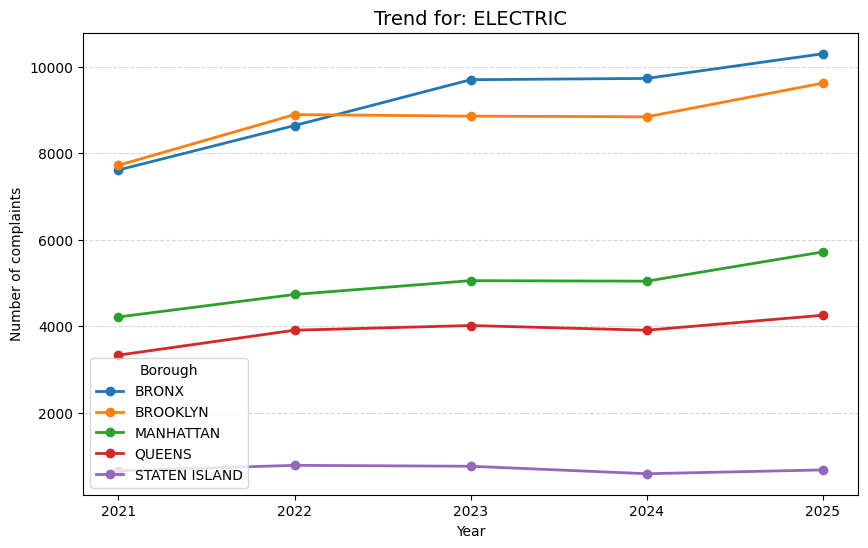

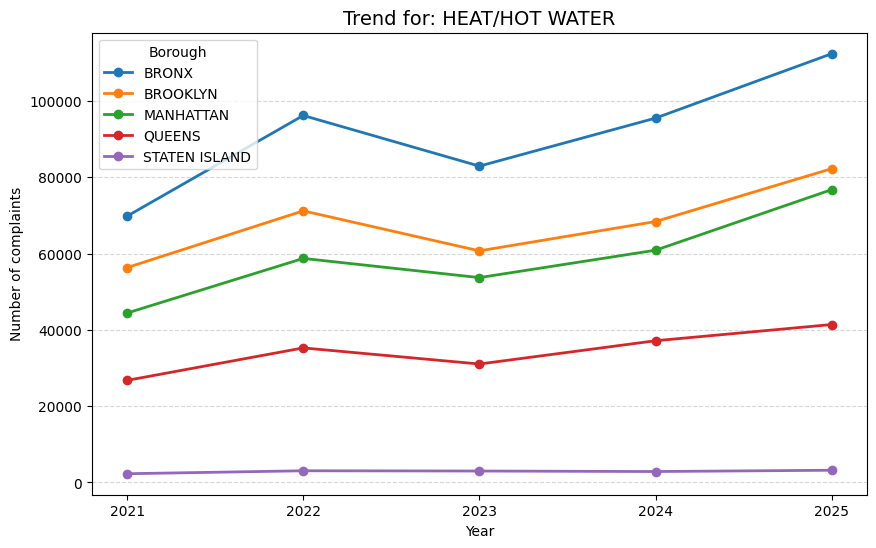

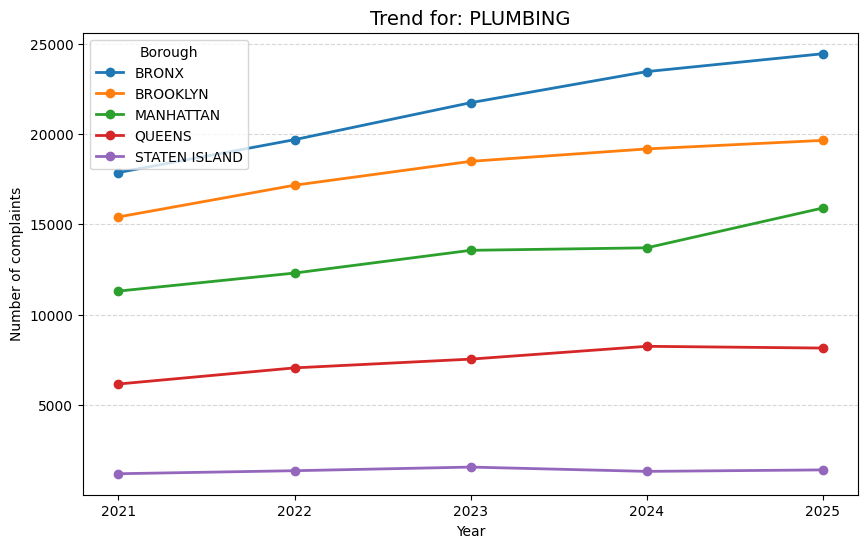

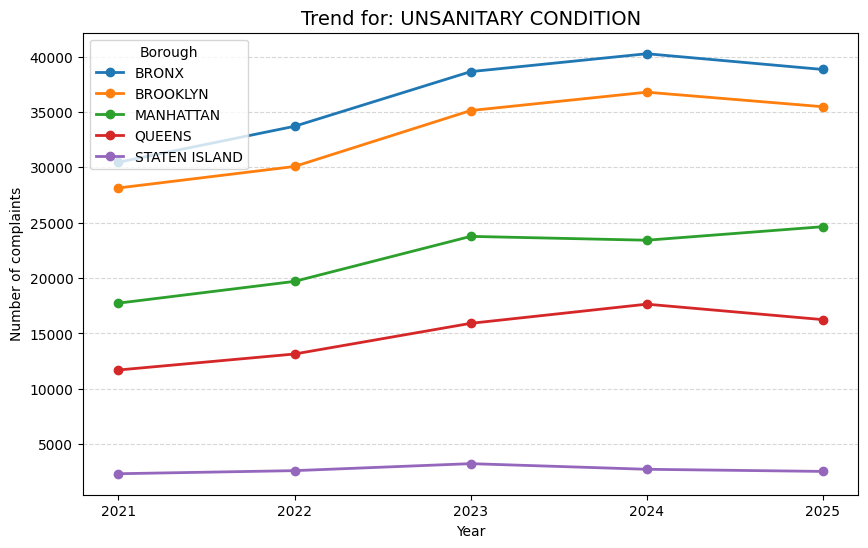

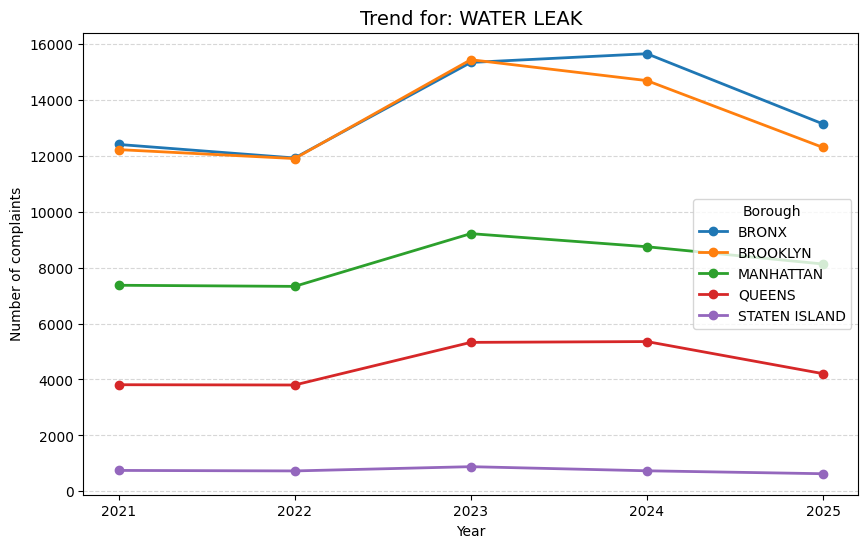

In [15]:
import matplotlib.pyplot as plt

# 1. Grouping logic (remains the same)
grouped = (df_complaints.groupby(["borough", "year", "complaint_type"]).size().reset_index(name="count"))
complaints = grouped["complaint_type"].unique()
years = sorted(grouped["year"].unique())

# 2. Iterate and create separate plots
for comp in complaints:
    # Create a new figure for each complaint type
    plt.figure(figsize=(10, 6))
    
    df_c = grouped[grouped["complaint_type"] == comp]
    
    for borough in df_c["borough"].unique():
        df_b = df_c[df_c["borough"] == borough]
        plt.plot(df_b["year"], df_b["count"], marker='o', linewidth=2, label=borough)

    # Formatting
    plt.title(f"Trend for: {comp}", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Number of complaints")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(fontsize=10, title="Borough")
    plt.xticks(years)
    
    # Clean up filename (replace slashes/spaces so it saves correctly)
    file_name = comp.replace("/", "_").replace(" ", "_").lower()
    
    # 3. Save each plot individually
    plt.savefig(f"data/visualizations/complaints/trend_{file_name}.png", dpi=300, bbox_inches='tight')
    
    # Show the plot
    plt.show()
    
    # Close the figure to free up memory
    plt.close()

## 4. Calendar plot

From the calendar plot we can see that for every year the number of complaints is higher between the months October to February, the winter.

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


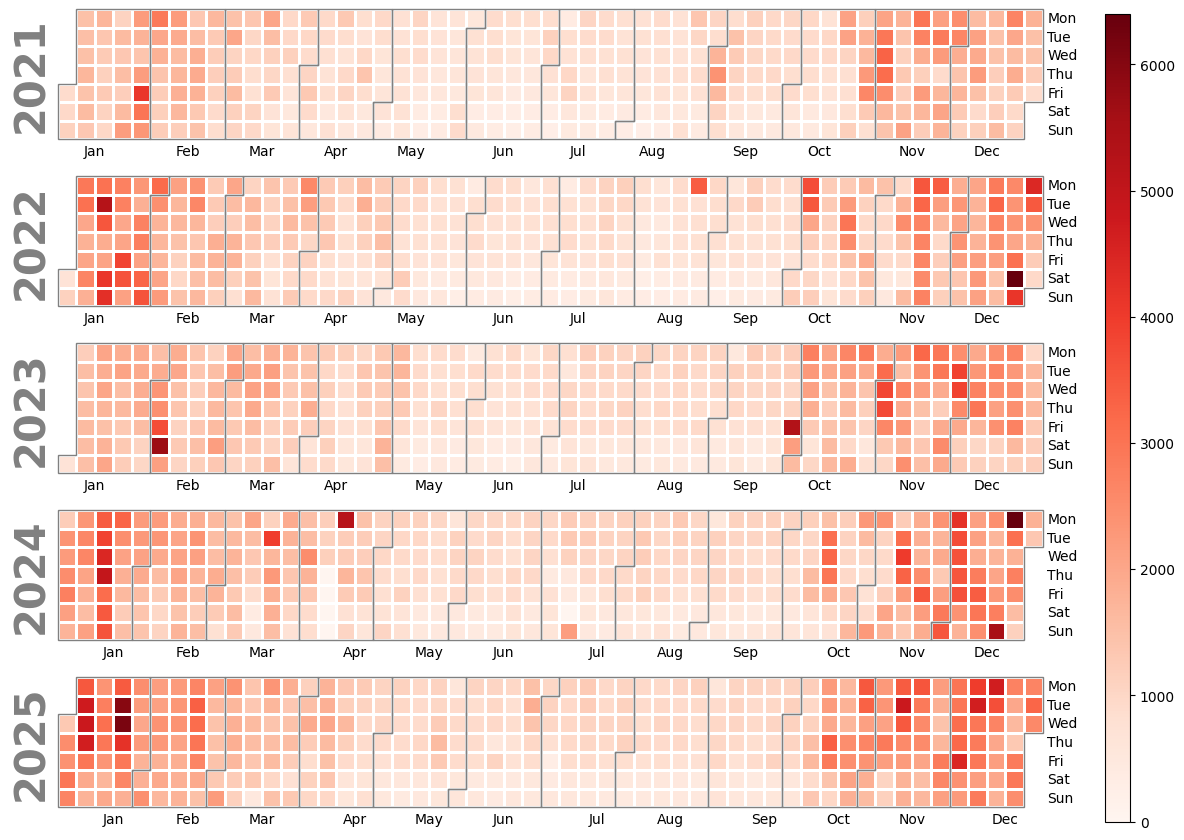

In [16]:
# replace time per 00:00:00
df_complaints["date"] = df_complaints["created_date"].dt.floor("D")
daily_counts = df_complaints.groupby("date").size()
calplot.calplot(daily_counts, cmap='Reds')
plt.show()

# Violations

## 1. Dataset Overview

Collect violations from NYC Open Data <br> 
(https://data.cityofnewyork.us/Housing-Development/Housing-Maintenance-Code-Violations/wvxf-dwi5/about_data)

- Inspection date: date when violation was observed
- Certified date: date when violation was certified
- Violation Status: 
    - An **OPEN** violation is a violation which is still active on the Department records. The property owner may or may not have corrected the physical condition if the status is open. 
    - A **CLOSE** violation is observed/verified as corrected by HPD or as certified by the landlord.

- from 1 january 2021 to 31 december 2025 (inspection date)
- violation classes
    - Class B (hazardous)
    - Class C (immediately hazardous)
- 3.993.658 violations
- violations along with zip code, borough and Registration ID

In [17]:
df_violations=pd.read_csv("data/violations20_25_original.csv")
print(df_violations.isna().sum())
df_violations.head()

violationid              0
zip                      0
class                    0
inspectiondate           0
certifieddate      2316829
boro                     0
violationstatus          0
registrationid           0
dtype: int64


,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid
0,18557284,10029,C,2025-12-31,NaN,MANHATTAN,Close,139824
1,18549728,11233,B,2025-12-31,NaN,BROOKLYN,Open,306116
2,18549953,10472,A,2025-12-31,2026-03-26T00:00:00.000,BRONX,Close,200630
3,18549868,10002,C,2025-12-31,2026-01-23T00:00:00.000,MANHATTAN,Close,111042
4,18549803,11233,A,2025-12-31,NaN,BROOKLYN,Open,306116


Keep only valid 5‑digit ZIP codes

In [18]:
df_violations["zip"] = df_violations["zip"].astype(int).astype(str)
df_violations = df_violations[df_violations["zip"].str.len() == 5]
df_violations["zip"] = df_violations["zip"].astype(int)

Check how many rows have certified date as NaN

In [19]:
no_viol=len(df_violations)
no_cd=df_violations["certifieddate"].isna().sum()
print(f"Number of violations: {no_viol}")
print(f"Number of violations without Certified Date: {no_cd}")
print(f"Number of violations with Certified Date: {no_viol-no_cd}")

Number of violations: 3993474
Number of violations without Certified Date: 2316704
Number of violations with Certified Date: 1676770


In [20]:
df_nan = df_violations[df_violations["certifieddate"].isna()]
status_counts=df_nan["violationstatus"].value_counts()
status_counts

violationstatus
Close    1253582
Open     1063122
Name: count, dtype: int64

A third of the violations have no certified date and a closed status. This could be related to the following reasons:
- the physical inspection never took place (building was demolished, violation was withdrawn)
- data entry errors

In [21]:
df_violations["inspectiondate"]=pd.to_datetime(df_violations["inspectiondate"])
print(f"Date range: {df_violations["inspectiondate"].min()}, {df_violations["inspectiondate"].max()}")

viol_class=list(df_violations["class"].unique())
print(f"Number of classes of violations: {len(viol_class)}")
print(f"Classes of violations: {viol_class}")

print(f"Number of different zipcodes: {len(df_violations["zip"].unique())}")
print(f"Number of different boroughs: {len(df_violations["boro"].unique())}")

Date range: 2021-01-01 00:00:00, 2025-12-31 00:00:00
Number of classes of violations: 3
Classes of violations: ['C', 'B', 'A']
Number of different zipcodes: 189
Number of different boroughs: 5


Remove rows with wrong data format

In [22]:
min_date = pd.Timestamp("2000-01-01")
max_date = pd.Timestamp("today")

df_violations["certifieddate"]=pd.to_datetime(df_violations["certifieddate"])

bad_dates = df_violations[
    (df_violations["certifieddate"] < min_date) | (df_violations["certifieddate"] > max_date) |
    (df_violations["inspectiondate"] < min_date) | (df_violations["inspectiondate"] > max_date) |
    (df_violations["certifieddate"] < df_violations["inspectiondate"])
]
print(f"Rows with wrong dates: {len(bad_dates)}")
print(bad_dates[["violationid", "inspectiondate", "certifieddate"]].head(20))

# Then drop or nullify them
#df_violations = df_violations[~(df_violations["certifieddate"] > max_date) & ~(df_violations["certifieddate"] < min_date)]

Rows with wrong dates: 18
         violationid inspectiondate certifieddate
3550893     14488562     2021-08-09    2021-08-06
3622703     14414511     2021-06-28    2021-06-26
3639197     14380200     2021-06-17    2021-06-01
3654098     14378938     2021-06-09    2021-06-07
3654099     14378939     2021-06-09    2021-06-07
3654103     14378943     2021-06-09    2021-06-07
3654107     14378948     2021-06-09    2021-06-07
3654109     14378951     2021-06-09    2021-06-07
3654114     14378955     2021-06-09    2021-06-07
3654115     14378958     2021-06-09    2021-06-07
3654116     14378959     2021-06-09    2021-06-07
3654117     14378961     2021-06-09    2021-06-07
3660448     14372531     2021-06-04    2021-06-01
3899241     14069428     2021-03-10    2021-03-09
3899246     14069444     2021-03-10    2021-03-09
3904291     14062768     2021-03-07    2100-10-04
3904437     14062769     2021-03-07    2100-10-04
3971507     13988819     2021-01-16    9202-01-20


In [23]:
df_violations = df_violations[
    ~(
        (df_violations["certifieddate"] < min_date) | (df_violations["certifieddate"] > max_date) |
        (df_violations["inspectiondate"] < min_date) | (df_violations["inspectiondate"] > max_date) |
        (df_violations["certifieddate"] < df_violations["inspectiondate"])
    )
]

## 2. Violations per class, borough and zip code

Class with most violations is B and borough is Brooklyn.

In [24]:
print(f"Number of violations per class:\n {df_violations["class"].value_counts()}")

viol_borough=df_violations["boro"].value_counts()
print(f"\nNumber of violations per borough:\n {viol_borough}")

viol_zip=df_violations["zip"].value_counts()
print(f"\nTop 5 Number of violations per zip code:\n {viol_zip.head(5)}")

Number of violations per class:
 class
B    1652157
C    1203647
A    1137652
Name: count, dtype: int64

Number of violations per borough:
 boro
BROOKLYN         1393605
BRONX            1340140
MANHATTAN         705191
QUEENS            494841
STATEN ISLAND      59679
Name: count, dtype: int64

Top 5 Number of violations per zip code:
 zip
11226    152198
10458    123280
10457    116706
10467    115124
10456    111070
Name: count, dtype: int64


The number of violations per 1000 people was computed for each borough and for each zip code, seperatly.

In [25]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
viol_boro = df_violations["boro"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
violations_per_1000 = (viol_boro / borough_pop) * 1000
df_boro = pd.DataFrame({
    "complaints": viol_boro,
    "population": borough_pop,
    "violations_per_1000": violations_per_1000
})
df_boro

,complaints,population,violations_per_1000
BRONX,1340140,1446788,926.286367
BROOKLYN,1393605,2648452,526.196057
MANHATTAN,705191,1638281,430.445693
QUEENS,494841,2330295,212.351226
STATEN ISLAND,59679,487155,122.505157


Number of violations per zip

In [26]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)

viol_zip_df = viol_zip.rename_axis("Zip Code").reset_index(name="violations")
viol_zip_pop = viol_zip_df.merge(zip_pop, on="Zip Code", how="left")

viol_zip_pop["violations_1000"]=(viol_zip_pop["violations"]/viol_zip_pop["Population"])*1000
viol_zip_pop

,Zip Code,violations,Population,violations_1000
0,11226,152198,95144.0,1599.659464
1,10458,123280,74898.0,1645.971855
2,10457,116706,79543.0,1467.206417
3,10467,115124,96421.0,1193.972267
4,10456,111070,87533.0,1268.892875
...,...,...,...,...
184,12238,3,NaN,NaN
185,10416,3,NaN,NaN
186,10105,2,NaN,NaN
187,10435,2,NaN,NaN


Save a choropleth map of complaints per 1000 per zip code. Zip codes with no value do not appear colored. <br>

In [27]:
min_range=viol_zip_pop["violations_1000"].min()
max_range=viol_zip_pop["violations_1000"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    viol_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="violations_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "violations_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/violations/zip_violations_map.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\2728969990.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\2728969990.py:45: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### Maps per zip and per class

In [28]:
zip_class=df_violations.groupby(["zip", "class"]).size().unstack(fill_value=0)
zip_class = zip_class.reset_index()

zip_class_df = zip_class.merge(zip_pop, left_on="zip", right_on="Zip Code", how="left")
zip_class_df

,zip,A,B,C,Zip Code,Population
0,10001,1505,1516,1460,10001.0,30511.0
1,10002,5709,5976,5401,10002.0,76873.0
2,10003,5021,4243,4270,10003.0,53560.0
3,10004,89,50,68,10004.0,3711.0
4,10005,119,33,34,10005.0,9439.0
...,...,...,...,...,...,...
184,11691,7832,12400,8533,11691.0,69359.0
185,11692,3074,4234,3306,11692.0,22734.0
186,11693,780,643,465,11693.0,13244.0
187,11694,2384,1308,1139,11694.0,21489.0


In [29]:
df_A = zip_class_df.reset_index()[["zip", "A", "Population"]]
df_A["viol_1000"]=(df_A["A"]/df_A["Population"])*1000

min_range=df_A["viol_1000"].min()
max_range=df_A["viol_1000"].max()

df_A.head()

,zip,A,Population,viol_1000
0,10001,1505,30511.0,49.326472
1,10002,5709,76873.0,74.265347
2,10003,5021,53560.0,93.745332
3,10004,89,3711.0,23.982754
4,10005,119,9439.0,12.607268


In [30]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_A,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/violations/zip_violA_map.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\997987809.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\997987809.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


In [31]:
df_B = zip_class_df.reset_index()[["zip", "B", "Population"]]
df_B["viol_1000"]=(df_B["B"]/df_B["Population"])*1000

min_range=df_B["viol_1000"].min()
max_range=df_B["viol_1000"].max()

df_B.head()

,zip,B,Population,viol_1000
0,10001,1516,30511.0,49.686998
1,10002,5976,76873.0,77.738608
2,10003,4243,53560.0,79.219567
3,10004,50,3711.0,13.473457
4,10005,33,9439.0,3.496133


In [32]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_B,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/violations/zip_violB_map.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\3967919889.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\3967919889.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


In [33]:
df_C = zip_class_df.reset_index()[["zip", "C", "Population"]]
df_C["viol_1000"]=(df_C["C"]/df_C["Population"])*1000

min_range=df_C["viol_1000"].min()
max_range=df_C["viol_1000"].max()

df_C.head()

,zip,C,Population,viol_1000
0,10001,1460,30511.0,47.851595
1,10002,5401,76873.0,70.258738
2,10003,4270,53560.0,79.723674
3,10004,68,3711.0,18.323902
4,10005,34,9439.0,3.602076


In [34]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_C,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/violations/zip_violC_map.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\178834239.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\178834239.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 3. Yearly trends per type and borough

Using year of inspection date

In [35]:
# df_violations["year"]=df_violations["inspectiondate"].dt.year
# year_type_viol = df_violations.groupby(["year", "class"]).size().unstack(fill_value=0)
# year_type_viol

In [36]:
# viol_types = year_type_viol.columns.tolist()
# years = sorted(year_type_viol.index.tolist())

# fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# axes = axes.flatten()

# for i, cat in enumerate(viol_types):
#     values = year_type_viol[cat].values
#     axes[i].plot(years, values, color="coral", marker='o')
#     axes[i].set_title(cat.capitalize(), fontsize=16)
#     axes[i].set_xlabel("Year", fontsize=14)
#     axes[i].set_xticks(years)
#     axes[i].set_xticklabels(years, fontsize=14)
#     axes[i].set_ylabel("Number of complaints", fontsize=14)
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# # Remove the unused subplot
# for j in range(len(viol_types), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Yearly Trends in Housing Complaint Types", fontsize=26)
# plt.tight_layout()
# plt.show()

Yearly trend per borough must take into account borough population. <br>
The Bronx clearly rates higher than all other boroughs for every year.

In [37]:
df_violations["year"]=df_violations["inspectiondate"].dt.year
year_boro_viol = df_violations.groupby(["year", "boro"]).size().unstack(fill_value=0)
year_boro_vnorm = year_boro_viol.div(borough_pop, axis=1) * 1000
print(year_boro_vnorm)

boro       BRONX    BROOKLYN  MANHATTAN     QUEENS  STATEN ISLAND
year                                                             
2021  139.158605  104.769881  82.758086  34.451003      15.401669
2022  150.867301   98.527366  81.283980  38.285711      19.209492
2023  180.569648  109.187933  88.549522  41.402913      22.417916
2024  241.396113  108.860950  91.962856  53.295827      32.905338
2025  214.294700  104.849927  85.891248  44.915772      32.570742


In [38]:
# boroughs = year_boro_viol.columns.tolist()

# fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# axes = axes.flatten()

# for i, borough in enumerate(boroughs):
#     axes[i].plot(
#         year_boro_vnorm.index,
#         year_boro_vnorm[borough],
#         marker='o',
#         color='coral'
#     )
#     axes[i].set_title(borough.capitalize(), fontsize=16)
#     axes[i].set_xlabel("Year", fontsize=14)
#     axes[i].set_xticks(years)
#     axes[i].set_xticklabels(years, fontsize=14)
#     axes[i].set_ylabel("Number of complaints", fontsize=14)
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# # Remove the unused subplot
# for j in range(len(boroughs), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Population‑Normalized Housing Complaint Rates by Borough", fontsize=26)
# plt.tight_layout()
# plt.show()

In [39]:
# grouped_viol = (df_violations.groupby(["boro", "year", "class"]).size().reset_index(name="count"))

# boroughs = year_boro_viol.columns.tolist()

# fig, axes = plt.subplots(3, 2, figsize=(20, 16))
# axes = axes.flatten()

# for i, borough in enumerate(boroughs):
#     df_b = grouped_viol[grouped_viol["boro"] == borough]

#     for viol_class in df_b["class"].unique():
#         df_t = df_b[df_b["class"] == viol_class]

#         axes[i].plot(
#             df_t["year"],
#             df_t["count"],
#             marker='o',
#             linewidth=2,
#             label=viol_class
#         )

#     axes[i].set_title(borough)
#     axes[i].set_xlabel("Year")
#     axes[i].set_ylabel("Number of complaints")
#     axes[i].grid(axis='y', linestyle='--', alpha=0.5)
#     axes[i].legend(fontsize=8)

# plt.suptitle("Complaint Trends per Borough (One Line per Complaint Type)", fontsize=24)
# plt.tight_layout()
# plt.show()

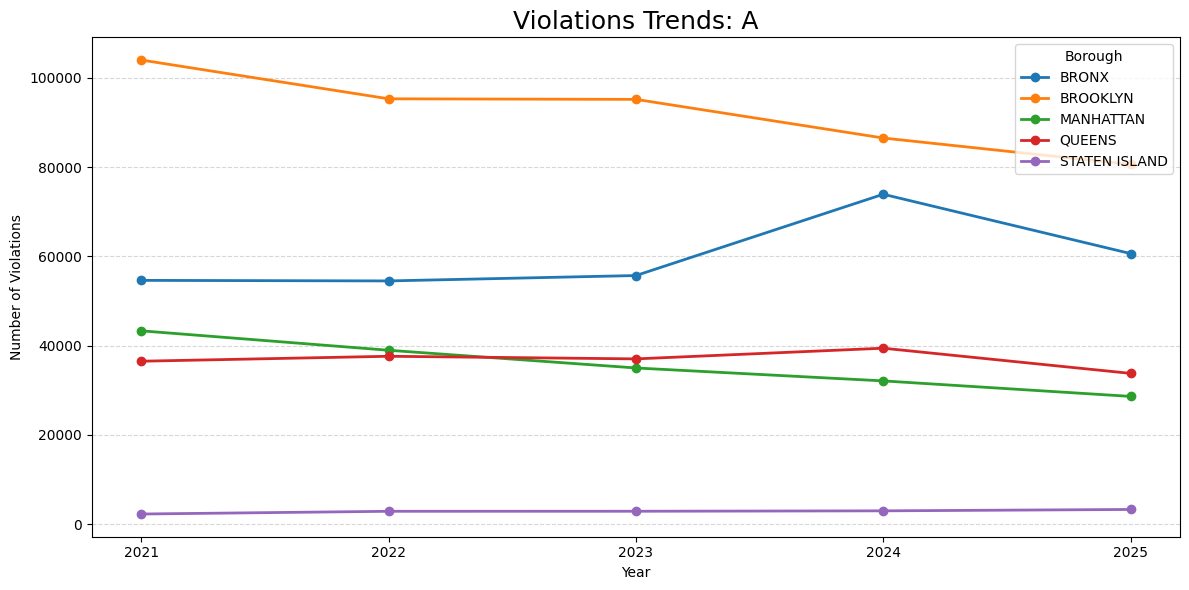

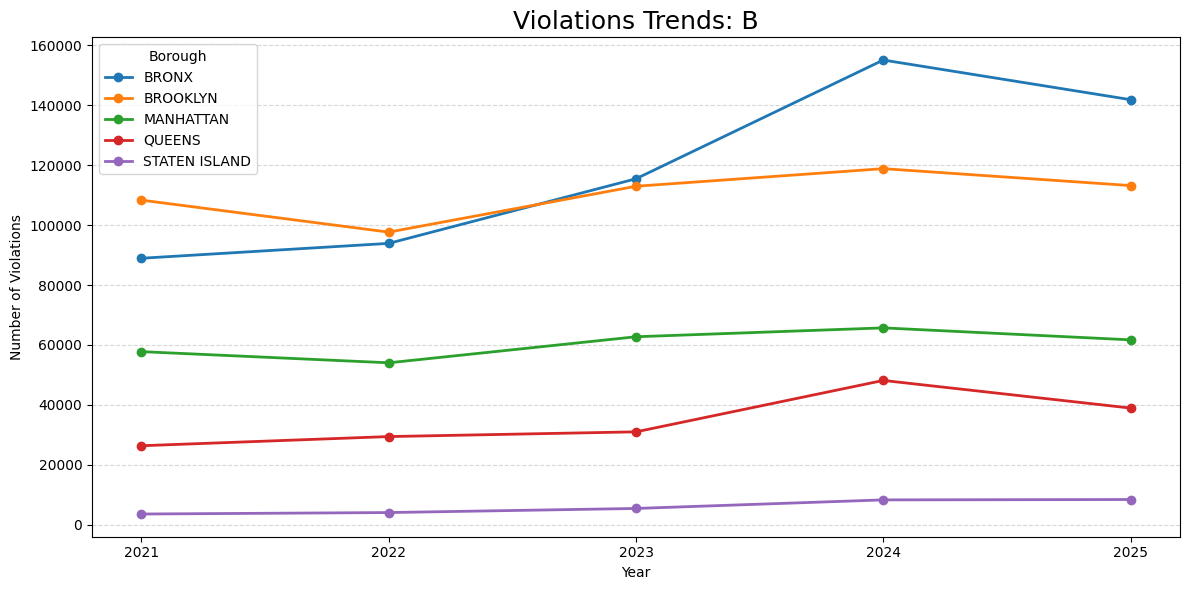

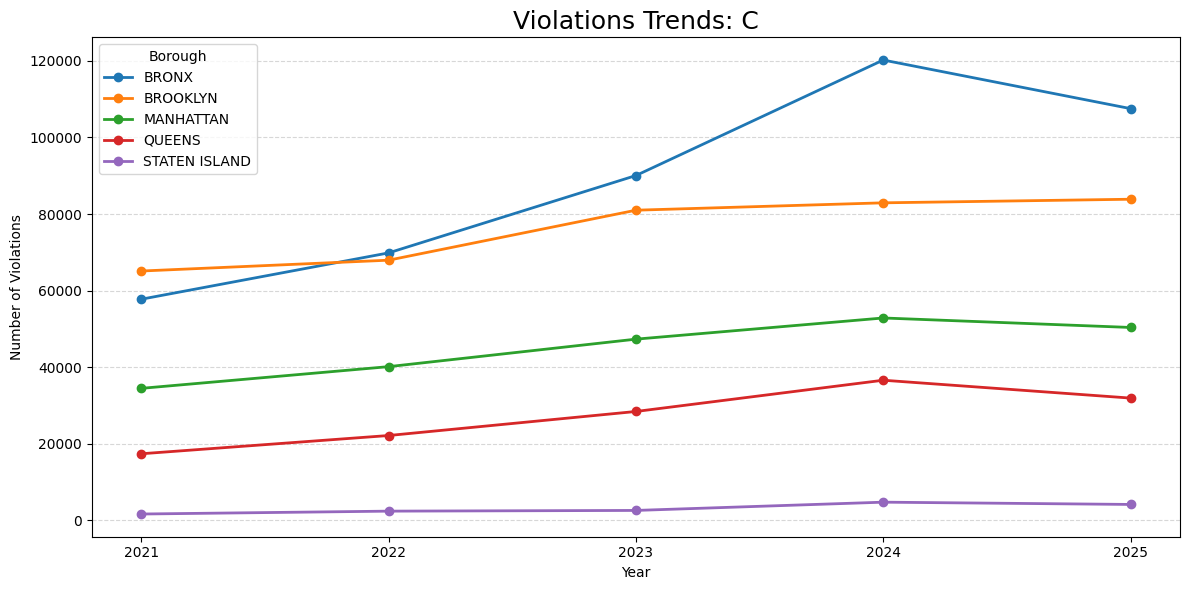

In [40]:
grouped_viol = (df_violations.groupby(["boro", "year", "class"]).size().reset_index(name="count"))
classes = sorted(grouped_viol["class"].unique()) # Sorting ensures consistent order

for clas in classes:
    # Create a fresh figure for each class
    plt.figure(figsize=(12, 6))
    
    df_c = grouped_viol[grouped_viol["class"] == clas]

    # Plot each borough as a line within this specific class
    for borough in df_c["boro"].unique():
        df_b = df_c[df_c["boro"] == borough]

        plt.plot(
            df_b["year"],
            df_b["count"],
            marker='o',
            linewidth=2,
            label=borough
        )

    # Styling for the individual photo
    plt.title(f"Violations Trends: {clas}", fontsize=18)
    plt.xlabel("Year")
    plt.ylabel("Number of Violations")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title="Borough", fontsize=10)
    
    # Ensure years on X-axis are integers (assuming 'years' list is defined)
    plt.xticks(years) 

    plt.tight_layout()

    
    
    # Save as an individual file
    filename = f"data/visualizations/violations/trend_{clas.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    
    # Show the plot in the notebook/console
    plt.show()

# APAGAR: Ratio violations/complaints

## 1. Only C

In [41]:
df_violations_C=df_violations[df_violations["class"]=="C"]

In [42]:
comp_zip = df_complaints.groupby("incident_zip").size().reset_index(name="complaints")
viol_zip = df_violations_C.groupby("zip").size().reset_index(name="violations")

In [43]:
zip_stats = comp_zip.merge(viol_zip,left_on="incident_zip",right_on="zip",how="inner")
zip_stats = zip_stats.drop(columns=["incident_zip"])
zip_stats = zip_stats[["zip", "complaints", "violations"]]
zip_stats["ratio"] = (zip_stats["violations"] / zip_stats["complaints"])
zip_stats

,zip,complaints,violations,ratio
0,10001,3715,1460,0.393001
1,10002,12252,5401,0.440826
2,10003,11914,4270,0.358402
3,10004,155,68,0.438710
4,10005,419,34,0.081146
...,...,...,...,...
175,11436,1955,534,0.273146
176,11691,17508,8533,0.487377
177,11692,5763,3306,0.573660
178,11693,1279,465,0.363565


In [44]:
min_range=zip_stats["ratio"].min()
max_range=zip_stats["ratio"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    zip_stats,
    geojson=zip_geo,
    locations="zip",
    color="ratio",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "ratio": True
    },
    labels={
        "ratio": "Ratio",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/ratio/zip_ratio_map_C.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\972098452.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 2. Only B and C

In [45]:
df_violations_BC = df_violations[df_violations["class"].isin(["B", "C"])]

comp_zip = df_complaints.groupby("incident_zip").size().reset_index(name="complaints")
viol_zip = df_violations_BC.groupby("zip").size().reset_index(name="violations")

zip_stats = comp_zip.merge(viol_zip,left_on="incident_zip",right_on="zip",how="inner")
zip_stats = zip_stats.drop(columns=["incident_zip"])
zip_stats = zip_stats[["zip", "complaints", "violations"]]
zip_stats["ratio"] = (zip_stats["violations"] / zip_stats["complaints"])
zip_stats

,zip,complaints,violations,ratio
0,10001,3715,2976,0.801077
1,10002,12252,11377,0.928583
2,10003,11914,8513,0.714538
3,10004,155,118,0.761290
4,10005,419,67,0.159905
...,...,...,...,...
176,11436,1955,1698,0.868542
177,11691,17508,20933,1.195625
178,11692,5763,7540,1.308346
179,11693,1279,1108,0.866302


In [46]:
min_range=zip_stats["ratio"].min()
max_range=zip_stats["ratio"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    zip_stats,
    geojson=zip_geo,
    locations="zip",
    color="ratio",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "ratio": True
    },
    labels={
        "ratio": "Ratio",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/ratio/zip_ratio_map_BC.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\3492172002.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 3. All

In [47]:
comp_zip = df_complaints.groupby("incident_zip").size().reset_index(name="complaints")
viol_zip = df_violations.groupby("zip").size().reset_index(name="violations")

zip_stats = comp_zip.merge(viol_zip,left_on="incident_zip",right_on="zip",how="inner")
zip_stats = zip_stats.drop(columns=["incident_zip"])
zip_stats = zip_stats[["zip", "complaints", "violations"]]
zip_stats["ratio"] = (zip_stats["violations"] / zip_stats["complaints"])
zip_stats

,zip,complaints,violations,ratio
0,10001,3715,4481,1.206191
1,10002,12252,17086,1.394548
2,10003,11914,13534,1.135974
3,10004,155,207,1.335484
4,10005,419,186,0.443914
...,...,...,...,...
177,11436,1955,2228,1.139642
178,11691,17508,28765,1.642963
179,11692,5763,10614,1.841749
180,11693,1279,1888,1.476153


In [48]:
min_range=zip_stats["ratio"].min()
max_range=zip_stats["ratio"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    zip_stats,
    geojson=zip_geo,
    locations="zip",
    color="ratio",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "ratio": True
    },
    labels={
        "ratio": "Ratio",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/ratio/zip_ratio_map_all.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1792214846.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


# Days to close a case

## 1. Dataset with certified date

*How long does it take owners to correct problems?* <br>
If violation has a certified date it means the violation was certified as corrected. Violation status might still be open due to burocracy.

In [49]:
df_cert = df_violations[df_violations["certifieddate"].notna()]
df_cert["inspectiondate"] = pd.to_datetime(df_cert["inspectiondate"])
df_cert["certifieddate"]  = pd.to_datetime(df_cert["certifieddate"])
df_cert["days_to_certify"] = (df_cert["certifieddate"] - df_cert["inspectiondate"]).dt.days

df_income = pd.read_csv("data/nyc_zipcode_income_class.csv")
df_cert = df_cert.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')
df_cert.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,days_to_certify,income_cat
0,18549953,10472,A,2025-12-31,2026-03-26,BRONX,Close,200630,2025,85,Low
1,18549868,10002,C,2025-12-31,2026-01-23,MANHATTAN,Close,111042,2025,23,Low
2,18550016,11207,B,2025-12-31,2026-02-20,BROOKLYN,Close,373957,2025,51,Low
3,18544318,11373,B,2025-12-31,2026-02-20,QUEENS,Close,406745,2025,51,Low
4,18544283,10468,B,2025-12-31,2026-02-20,BRONX,Close,207290,2025,51,Low


### 1.1. All classes

Group by zip and average

In [50]:
cert_zip = df_cert.groupby("zip")["days_to_certify"].median().reset_index()

In [51]:
cert_zip["days_to_certify"].describe()

count    182.000000
mean      29.862637
std        9.243952
min        8.000000
25%       26.000000
50%       30.000000
75%       32.000000
max      107.000000
Name: days_to_certify, dtype: float64

In [52]:
min_range=cert_zip["days_to_certify"].min()
max_range=cert_zip["days_to_certify"].max()
min_range, max_range

(np.float64(8.0), np.float64(107.0))

In [53]:
p95 = cert_zip["days_to_certify"].quantile(0.95)

In [54]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    cert_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_to_certify",
    mapbox_style="carto-positron",
    color_continuous_scale="RdYlGn_r",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_to_certify": True
    },
    labels={
        "days_to_certify": "days_to_certify",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days to close")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_days_all.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1379379391.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1379379391.py:43: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 1.2 Only C

In [55]:
df_cert_C=df_cert[df_cert["class"]=="C"]
cert_zip = df_cert_C.groupby("zip")["days_to_certify"].median().reset_index()

In [56]:
min_range=cert_zip["days_to_certify"].min()
max_range=cert_zip["days_to_certify"].max()
min_range, max_range

(np.float64(6.5), np.float64(113.0))

In [57]:
p95 = cert_zip["days_to_certify"].quantile(0.95)

In [58]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    cert_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_to_certify",
    mapbox_style="carto-positron",
    color_continuous_scale="RdYlGn_r",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_to_certify": True
    },
    labels={
        "days_to_certify": "days_to_certify",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days to close")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_days_C.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\274147709.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\274147709.py:43: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 1.3. B and C

In [59]:
df_cert_BC=df_cert[df_cert["class"].isin(["B", "C"])]
cert_zip = df_cert_BC.groupby("zip")["days_to_certify"].median().reset_index()

In [60]:
min_range=cert_zip["days_to_certify"].min()
max_range=cert_zip["days_to_certify"].max()
min_range, max_range

(np.float64(8.0), np.float64(83.0))

In [61]:
p95 = cert_zip["days_to_certify"].quantile(0.95)

In [62]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    cert_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_to_certify",
    mapbox_style="carto-positron",
    color_continuous_scale="RdYlGn_r",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_to_certify": True
    },
    labels={
        "days_to_certify": "days_to_certify",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days to close")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_days_BC.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\3844586172.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\3844586172.py:43: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 1.4. Per registration ID

In [63]:
df_reg = df_cert.groupby('registrationid')['days_to_certify'].median().reset_index()
df_reg.columns = ['registrationid', 'median_days_to_certify']
df_reg = df_reg.sort_values('median_days_to_certify', ascending=False).reset_index(drop=True)
df_reg

,registrationid,median_days_to_certify
0,387390,1818.0
1,135336,1815.5
2,346630,1789.0
3,324520,1764.5
4,819824,1760.0
...,...,...
47395,314013,0.0
47396,313821,0.0
47397,611630,0.0
47398,137645,0.0


## 2. Dataset with certified data as NaN

In [64]:
df_nan = df_violations[df_violations["certifieddate"].isna()]
df_nan = df_nan.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')
df_nan

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,income_cat
0,18557284,10029,C,2025-12-31,NaT,MANHATTAN,Close,139824,2025,Low
1,18549728,11233,B,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low
2,18549803,11233,A,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low
3,18549800,11233,C,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low
4,18549767,11233,B,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low
...,...,...,...,...,...,...,...,...,...,...
2316699,13967434,11216,B,2021-01-01,NaT,BROOKLYN,Open,317170,2021,Middle-High
2316700,13967437,11216,C,2021-01-01,NaT,BROOKLYN,Open,317170,2021,Middle-High
2316701,13967438,11416,B,2021-01-01,NaT,QUEENS,Open,0,2021,Low-Middle
2316702,13967439,11416,B,2021-01-01,NaT,QUEENS,Open,0,2021,Low-Middle


In [65]:
df_nan["violationstatus"].value_counts()

violationstatus
Close    1253582
Open     1063122
Name: count, dtype: int64

In [66]:
df_open = df_nan[df_nan["violationstatus"]=="Open"]

today = pd.Timestamp("today")
df_open["days_open"] = (pd.to_datetime("2025-12-31") - df_open["inspectiondate"]).dt.days
df_open.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,income_cat,days_open
1,18549728,11233,B,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low,0
2,18549803,11233,A,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low,0
3,18549800,11233,C,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low,0
4,18549767,11233,B,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low,0
5,18549738,11233,C,2025-12-31,NaT,BROOKLYN,Open,306116,2025,Low,0


In [67]:
open_zip = df_open.groupby("zip")["days_open"].median().reset_index()
open_zip

,zip,days_open
0,10001,679.0
1,10002,889.0
2,10003,788.0
3,10004,842.0
4,10005,1526.0
...,...,...
178,11691,783.0
179,11692,791.0
180,11693,845.0
181,11694,800.0


In [68]:
min_range=open_zip["days_open"].min()
max_range=open_zip["days_open"].max()
min_range, max_range

(np.float64(124.0), np.float64(1526.0))

In [69]:
open_zip["days_open"].describe()

count     183.000000
mean      708.150273
std       170.369582
min       124.000000
25%       624.500000
50%       713.000000
75%       786.500000
max      1526.000000
Name: days_open, dtype: float64

In [70]:
p95 = open_zip["days_open"].quantile(0.95)

In [71]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    open_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_open",
    mapbox_style="carto-positron",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_open": True
    },
    labels={
        "days_open": "days_open",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days Open")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_open_all.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1820324793.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\1820324793.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 2.1 Only C

In [72]:
df_open_C=df_open[df_open["class"]=="C"]
open_zip = df_open_C.groupby("zip")["days_open"].median().reset_index()

min_range=open_zip["days_open"].min()
max_range=open_zip["days_open"].max()
min_range, max_range

(np.float64(59.0), np.float64(1107.0))

In [73]:
p95 = open_zip["days_open"].quantile(0.95)

In [74]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    open_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_open",
    mapbox_style="carto-positron",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_open": True
    },
    labels={
        "days_open": "days_open",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days Open")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_open_c.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\363695745.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\363695745.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 2.2 only B and C

In [75]:
df_open_BC=df_open[df_open["class"].isin(["B", "C"])]
open_zip = df_open_BC.groupby("zip")["days_open"].median().reset_index()

min_range=open_zip["days_open"].min()
max_range=open_zip["days_open"].max()
min_range, max_range

(np.float64(139.0), np.float64(1478.0))

In [76]:
p95 = open_zip["days_open"].quantile(0.95)

In [77]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    open_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_open",
    mapbox_style="carto-positron",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_open": True
    },
    labels={
        "days_open": "days_open",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days Open")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_open_bc.html")

C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\2643115720.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Diogo Forte\AppData\Local\Temp\ipykernel_25936\2643115720.py:42: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


### 2.3 per registration ID

In [78]:
df_reg = df_cert.groupby('registrationid')['days_to_certify'].median().reset_index()
df_reg.columns = ['registrationid', 'median_days_open']
df_reg = df_reg.sort_values('median_days_open', ascending=False).reset_index(drop=True)
df_reg

,registrationid,median_days_open
0,387390,1818.0
1,135336,1815.5
2,346630,1789.0
3,324520,1764.5
4,819824,1760.0
...,...,...
47395,314013,0.0
47396,313821,0.0
47397,611630,0.0
47398,137645,0.0


# Violations per Registration ID

In [79]:
df_violations.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year
0,18557284,10029,C,2025-12-31,NaT,MANHATTAN,Close,139824,2025
1,18549728,11233,B,2025-12-31,NaT,BROOKLYN,Open,306116,2025
2,18549953,10472,A,2025-12-31,2026-03-26,BRONX,Close,200630,2025
3,18549868,10002,C,2025-12-31,2026-01-23,MANHATTAN,Close,111042,2025
4,18549803,11233,A,2025-12-31,NaT,BROOKLYN,Open,306116,2025


## 1. Violations per registration ID and per income area

Grouping by registration ID allows us to see how many violations each registration ID has. <br>
Then we can see how many registration IDs make up 20% of the violations.

In [80]:
viol_reg = df_violations.groupby('registrationid').size().sort_values(ascending=False)

total_violations = len(df_violations)
cumulative_pct = viol_reg.cumsum() / total_violations

n_needed = (cumulative_pct <= 0.20).sum() + 1
top_reg_ids = cumulative_pct[cumulative_pct <= 0.20].index
print(f"{n_needed} registration IDs have 20% of all violations")

df_top10 = df_violations[df_violations['registrationid'].isin(top_reg_ids)]
df_top10.head(5)

872 registration IDs have 20% of all violations


,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year
0,18557284,10029,C,2025-12-31,NaT,MANHATTAN,Close,139824,2025
2,18549953,10472,A,2025-12-31,2026-03-26,BRONX,Close,200630,2025
18,18549998,10460,B,2025-12-31,2026-02-25,BRONX,Close,0,2025
19,18550087,10459,B,2025-12-31,NaT,BRONX,Close,224577,2025
30,18550088,10459,B,2025-12-31,NaT,BRONX,Close,224577,2025


Add a variable income_cat corresponding to the income group of the zip code of the violation.

In [81]:
df_income = pd.read_csv("data/nyc_zipcode_income_class.csv")
df_top10 = df_top10.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')
df_top10

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,income_cat
0,18557284,10029,C,2025-12-31,NaT,MANHATTAN,Close,139824,2025,Low
1,18549953,10472,A,2025-12-31,2026-03-26,BRONX,Close,200630,2025,Low
2,18549998,10460,B,2025-12-31,2026-02-25,BRONX,Close,0,2025,Low
3,18550087,10459,B,2025-12-31,NaT,BRONX,Close,224577,2025,Low
4,18550088,10459,B,2025-12-31,NaT,BRONX,Close,224577,2025,Low
...,...,...,...,...,...,...,...,...,...,...
798225,13968132,11226,B,2021-01-02,2021-01-21,BROOKLYN,Close,312372,2021,Low-Middle
798226,13968130,11226,B,2021-01-02,2021-01-21,BROOKLYN,Close,312372,2021,Low-Middle
798227,13968129,11226,B,2021-01-02,2021-01-21,BROOKLYN,Close,312372,2021,Low-Middle
798228,13967438,11416,B,2021-01-01,NaT,QUEENS,Open,0,2021,Low-Middle


Get total violations per registration, discriminating the number of violations per each income cat value

In [82]:
total = df_top10.groupby('registrationid').size().rename('total_violations')
by_income = df_top10.groupby(['registrationid', 'income_cat']).size().unstack(fill_value=0)
df_summary = pd.concat([total, by_income], axis=1).reset_index()
df_summary = df_summary.sort_values('total_violations', ascending=False).reset_index(drop=True)
df_summary.head()

,registrationid,total_violations,High,Low,Low-Middle,Middle-High
0,0,96183,6725,38382,34232,16843
1,374310,4398,0,4398,0,0
2,374351,3264,0,3264,0,0
3,221675,3254,0,3254,0,0
4,374352,2927,0,2927,0,0


In [83]:
print("High > 0:", (df_summary['High'] > 0).sum())
print("Middle-High > 0:", (df_summary['Middle-High'] > 0).sum())

High > 0: 8
Middle-High > 0: 26


This is not surprisng bc we saw that most violations were in low income areas.

## 2. Get contacts of owerns of these 20% top registrations

In [84]:
df_contacts=pd.read_csv("data/contacts_original.csv")
df_contacts.head()

,registrationcontactid,registrationid,type,corporationname,businessstreetname,businesshousenumber,firstname,lastname
0,12473203,124732,CorporateOwner,KOSCAL 59 LLC,3 59TH ST,346,NaN,NaN
1,12473204,124732,Agent,TZM REALTY PROPERTIES LLC,E 59TH ST,346,ANTHONY,ZACHARIADIS
2,12473205,124732,HeadOfficer,NaN,E 59TH ST,346,KOSTAS,ZACHARIADIS
3,12473206,124732,Officer,NaN,E 59TH ST,346,ANTHONY,ZAHARIADIS
4,12473213,124732,SiteManager,NaN,NaN,NaN,ROSALIO,PEREA


We want to know who owns the buildings not who manages them

In [85]:
owner_types = ['CorporateOwner', 'Shareholder', 'IndividualOwner']
df_owners_top = df_contacts[(df_contacts['registrationid'].isin(top_reg_ids)) &(df_contacts['type'].isin(owner_types))]
df_owners_top.head()

,registrationcontactid,registrationid,type,corporationname,businessstreetname,businesshousenumber,firstname,lastname
492,11579703,115797,CorporateOwner,NORTHERN MAN EQUITIES,116 STREET,87-14,NaN,NaN
518,10732603,107326,CorporateOwner,PASCOL REALTY INC,TARRYTOWN ROAD,455,NaN,NaN
674,20524803,205248,CorporateOwner,686 E 234 REALTY LLC,STRATFORD RD,470,NaN,NaN
3490,50094410,500944,Shareholder,NaN,Northern Blvd,1044,Allan,Arker
3596,20700603,207006,CorporateOwner,643 SOUTHERN LLC,S BROADWAY,20,NaN,NaN


We can see most owners are corporate

In [86]:
df_owners_top["type"].value_counts()

type
CorporateOwner     865
Shareholder        177
IndividualOwner      7
Name: count, dtype: int64

Lets see if a owner has different registration IDs

In [87]:
df_owners_top['match_key'] = df_owners_top.apply(lambda r: r['corporationname'] if r['type'] == 'CorporateOwner' else f"{r['firstname']} {r['lastname']}", axis=1)
df_owners_top['match_key'] = df_owners_top['match_key'].str.strip().str.upper()

In [88]:
owner_groups = df_owners_top.groupby('match_key')['registrationid'].apply(set).reset_index()
owner_groups.columns = ['match_key', 'registrationids']

shared_owners = owner_groups[owner_groups['registrationids'].apply(len) > 1]
print(f"{len(shared_owners)} owners appear across multiple registrations")

75 owners appear across multiple registrations


## 3. Get number of buildings of owners, also per income

For these 75 owners, lets see how many buildings they have

In [89]:
df_registrations=pd.read_csv("data/registrations_original.csv")
df_registrations = df_registrations.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')
df_registrations.head()

,registrationid,buildingid,boro,zip,lastregistrationdate,income_cat
0,825850,271859,BROOKLYN,11234.0,2026-03-19T00:00:00.000,Middle-High
1,131572,169,MANHATTAN,10003.0,2025-08-13T00:00:00.000,High
2,109808,245,MANHATTAN,10028.0,2025-08-08T00:00:00.000,High
3,420463,810843,QUEENS,11434.0,2026-03-31T00:00:00.000,Low-Middle
4,335058,383549,BROOKLYN,11231.0,2026-03-30T00:00:00.000,High


In [90]:
buildings_per_reg = df_registrations.groupby('registrationid')['buildingid'].nunique()
shared_owners['total_buildings'] = shared_owners['registrationids'].apply(
    lambda ids: buildings_per_reg.reindex(ids).sum()
)

buildings_per_reg_income = df_registrations.groupby(['registrationid', 'income_cat'])['buildingid'].nunique().unstack(fill_value=0)

income_counts = shared_owners['registrationids'].apply(
    lambda ids: buildings_per_reg_income.reindex(ids).sum()
)

shared_owners = pd.concat([shared_owners, income_counts], axis=1)
shared_owners = shared_owners.sort_values('total_buildings', ascending=False).reset_index(drop=True)
shared_owners.head()

,match_key,registrationids,total_buildings,High,Low,Low-Middle,Middle-High
0,ZOHAR LEVY,"{326593, 201030, 203559, 305800, 202505, 21082...",15,0,15,0,0
1,ALEX ARKER,"{500928, 500943, 500944, 500945, 500976, 50098...",9,0,9,0,0
2,ALLAN ARKER,"{500928, 500943, 500944, 500945, 500976, 50098...",9,0,9,0,0
3,JOSEPH POPACK,"{306562, 301196, 306988, 300557, 302065, 30178...",8,0,3,5,0
4,ANTHONY GAZIVODA,"{200160, 201890, 200611, 204906, 203851, 22135...",7,0,6,1,0


In [91]:
display_cols = shared_owners[['match_key', 'total_buildings', 'High', 'Middle-High', 'Low-Middle', 'Low']].copy()
display_cols.columns = ['Owner', 'Buildings', 'High Income', 'Mid-High Income', 'Low-Mid Income', 'Low Income']

In [92]:
style = """<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
* { box-sizing: border-box; margin: 0; padding: 0; }
body { font-family: 'DM Sans', sans-serif; background: #ffffff; color: #1a1814; }

.table-wrapper {
  overflow-y: auto;
  max-height: 480px;
}

table {
  width: 100%;
  border-collapse: collapse;
  font-size: 13px;
}

thead tr {
  background: #1a1814;
}
thead th {
  position: sticky;
  top: 0;
  font-family: 'DM Mono', monospace;
  font-size: 10px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  color: #7a7166;
  padding: 12px 16px;
  text-align: left;
  font-weight: 400;
  z-index: 1;
}

tbody td {
  padding: 10px 16px;
  border-bottom: 1px solid #e2ddd6;
  color: #4a4540;
  font-weight: 300;
}
tbody tr:last-child td { border-bottom: none; }
tbody tr:hover td { background: #f7f4ef; }

td:first-child { color: #1a1814; font-weight: 500; }
td:nth-child(2) { color: #1a1814; font-weight: 500; }

.pill {
  display: inline-block;
  font-family: 'DM Mono', monospace;
  font-size: 10px;
  padding: 2px 8px;
  border-radius: 3px;
}
.pill-low    { background: rgba(192,57,43,0.12);  color: #c0392b; border: 1px solid #c0392b; }
.pill-mid    { background: rgba(212,134,10,0.12);  color: #d4860a; border: 1px solid #d4860a; }
.pill-high   { background: rgba(44,122,107,0.12); color: #2c7a6b; border: 1px solid #2c7a6b; }
</style>
</head>
<body>
<div class="table-wrapper">
"""

closing = """
</div>
</body>
</html>
"""

html_table = display_cols.to_html(index=False, classes='owners-table', border=0)

with open('data/visualizations/owners_table.html', 'w') as f:
    f.write(style + html_table + closing)